# 02 - Weekly Stress EDA

## Business Question
> Bagaimana pola stres mingguan mahasiswa berdasarkan `average_stress_score`, `dominant_stress_level`, `stress_trend`, `high_stress_days`, dan `main_trigger`?

## Sub-Business Questions
- Apakah jumlah high_stress_days berkaitan dengan peningkatan average_stress_score?
- Stress trend apa yang paling sering muncul pada mahasiswa?
- Faktor mingguan apa yang paling sering menjadi main_trigger stres?
- Apakah average_sleep_hours memiliki hubungan dengan dominant_stress_level?
- Bagaimana hubungan antara average_screen_time dan stress_trend mingguan?
- Apakah mahasiswa dengan average_study_hours tinggi cenderung memiliki stres mingguan lebih tinggi?

# 0. Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

NOTEBOOK_DIR = Path('__file__').resolve().parent
BASE_DIR     = NOTEBOOK_DIR.parents[2]

DATA_PROCESSED  = BASE_DIR / 'data/processed/'
OUTPUT_FIGURES  = BASE_DIR / 'outputs/figures/eda/'
OUTPUT_REPORTS  = BASE_DIR / 'outputs/reports/'

OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_REPORTS.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')
print(f'BASE_DIR       : {BASE_DIR}')
print(f'DATA_PROCESSED : {DATA_PROCESSED}')

Libraries loaded.
BASE_DIR       : D:\code\stress_detector_datascience
DATA_PROCESSED : D:\code\stress_detector_datascience\data\processed


# 1. Load


In [2]:
weekly_eda = pd.read_csv(DATA_PROCESSED / 'weekly_summaries_clean.csv')

print(f'weekly_eda shape: {weekly_eda.shape}')
weekly_eda.head(3)

weekly_eda shape: (3600, 13)


,id,user_id,week_start,week_end,average_stress_score,average_sleep_hours,average_screen_time,average_study_hours,high_stress_days,dominant_stress_level,stress_trend,main_trigger,created_at
0,1,1,2026-01-01,2026-01-07,52.92,7.10,7.23,3.46,0,Medium,Stable,Low Mood,2026-01-07 21:00:00
1,2,1,2026-01-08,2026-01-14,49.64,6.73,7.90,3.24,0,Medium,Stable,Academic Pressure,2026-01-14 21:00:00
2,3,1,2026-01-15,2026-01-21,50.77,7.53,8.34,3.56,0,Medium,Stable,Academic Pressure,2026-01-21 21:00:00


In [3]:
# Konstanta urutan dan palette
TREND_ORDER   = ['Increasing', 'Stable', 'Decreasing']
LEVEL_ORDER   = ['Low', 'Medium', 'High']
TREND_PALETTE = {'Increasing': '#F44336', 'Stable': '#FF9800', 'Decreasing': '#4CAF50'}
LEVEL_PALETTE = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

WEEKLY_NUM_COLS = ['average_sleep_hours', 'average_screen_time',
                   'average_study_hours', 'high_stress_days']

print('Columns:', weekly_eda.columns.tolist())
print('\nMissing values:')
print(weekly_eda.isnull().sum())

Columns: ['id', 'user_id', 'week_start', 'week_end', 'average_stress_score', 'average_sleep_hours', 'average_screen_time', 'average_study_hours', 'high_stress_days', 'dominant_stress_level', 'stress_trend', 'main_trigger', 'created_at']

Missing values:
id                       0
user_id                  0
week_start               0
week_end                 0
average_stress_score     0
average_sleep_hours      0
average_screen_time      0
average_study_hours      0
high_stress_days         0
dominant_stress_level    0
stress_trend             0
main_trigger             0
created_at               0
dtype: int64


# 2. Distribusi Target Mingguan 

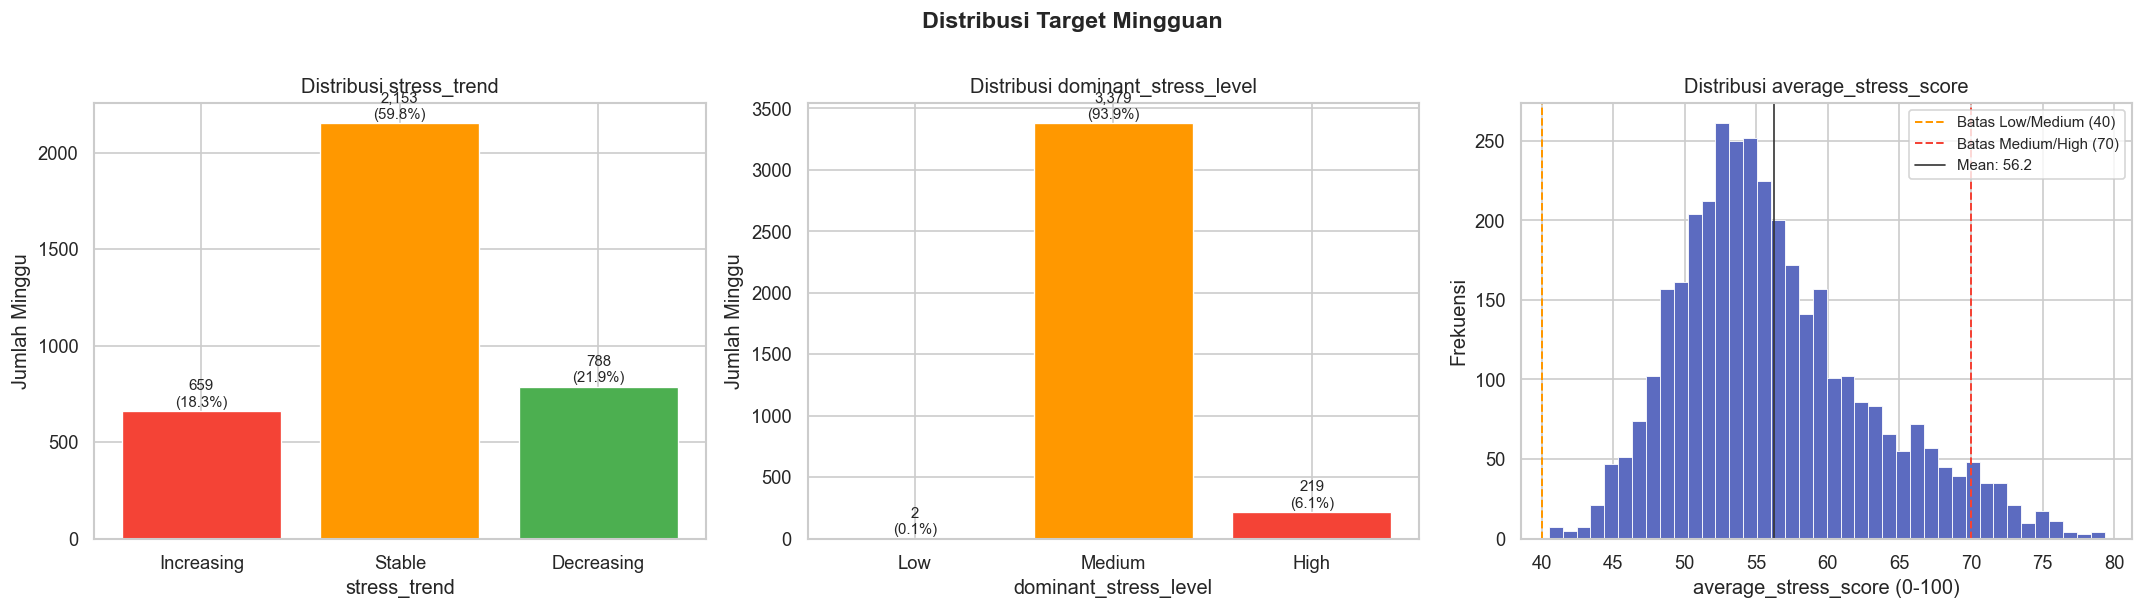


--- Summary Distribusi Target Mingguan ---

stress_trend:
  Increasing  :   659 (18.3%)
  Stable      : 2,153 (59.8%)
  Decreasing  :   788 (21.9%)

dominant_stress_level:
  Low     :     2 (0.1%)
  Medium  : 3,379 (93.9%)
  High    :   219 (6.1%)

average_stress_score:
count    3600.00
mean       56.21
std         6.77
min        40.49
25%        51.47
50%        55.00
75%        59.86
max        79.34
Name: average_stress_score, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Target Mingguan', fontsize=14, fontweight='bold', y=1.01)

# --- Plot 1: Bar chart stress_trend ---
trend_counts = weekly_eda['stress_trend'].value_counts().reindex(TREND_ORDER)
bars = axes[0].bar(trend_counts.index, trend_counts.values,
                   color=[TREND_PALETTE[t] for t in trend_counts.index],
                   edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribusi stress_trend')
axes[0].set_xlabel('stress_trend')
axes[0].set_ylabel('Jumlah Minggu')
for bar, val in zip(bars, trend_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}\n({val/len(weekly_eda)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

# --- Plot 2: Bar chart dominant_stress_level ---
level_counts = weekly_eda['dominant_stress_level'].value_counts().reindex(LEVEL_ORDER)
bars2 = axes[1].bar(level_counts.index, level_counts.values,
                    color=[LEVEL_PALETTE[l] for l in level_counts.index],
                    edgecolor='white', linewidth=0.8)
axes[1].set_title('Distribusi dominant_stress_level')
axes[1].set_xlabel('dominant_stress_level')
axes[1].set_ylabel('Jumlah Minggu')
for bar, val in zip(bars2, level_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}\n({val/len(weekly_eda)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

# --- Plot 3: Histogram average_stress_score ---
axes[2].hist(weekly_eda['average_stress_score'], bins=40,
             color='#5C6BC0', edgecolor='white', linewidth=0.5)
axes[2].set_title('Distribusi average_stress_score')
axes[2].set_xlabel('average_stress_score (0-100)')
axes[2].set_ylabel('Frekuensi')
axes[2].axvline(40, color='#FF9800', linestyle='--', linewidth=1.2, label='Batas Low/Medium (40)')
axes[2].axvline(70, color='#F44336', linestyle='--', linewidth=1.2, label='Batas Medium/High (70)')
mean_score = weekly_eda['average_stress_score'].mean()
axes[2].axvline(mean_score, color='#333', linestyle='-', linewidth=1,
                label=f'Mean: {mean_score:.1f}')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '01_weekly_target_distribution.png', bbox_inches='tight')
plt.show()

print('\n--- Summary Distribusi Target Mingguan ---')
print('\nstress_trend:')
for t in TREND_ORDER:
    n = trend_counts[t]
    print(f'  {t:12s}: {n:5,} ({n/len(weekly_eda)*100:.1f}%)')

print('\ndominant_stress_level:')
for l in LEVEL_ORDER:
    n = level_counts[l]
    print(f'  {l:8s}: {n:5,} ({n/len(weekly_eda)*100:.1f}%)')

print(f'\naverage_stress_score:')
print(weekly_eda['average_stress_score'].describe().round(2))

## Insight

- `stress_trend` didominasi oleh Stable (59.8%, 2.153 minggu), artinya lebih dari separuh minggu yang dialami mahasiswa kondisi stresnya tidak berubah signifikan. Hanya 18.3% minggu yang menunjukkan tren *Increasing meskipun kecil secara proporsi, kelompok ini tetap perlu diwaspadai karena berpotensi akumulatif.

- `dominant_stress_level` sangat terpusat di Medium (93.9%, 3.379 minggu). Kategori Low hampir tidak ada (hanya 2 minggu, 0.1%), sementara High hanya 6.1%. Ini menunjukkan bahwa data ini merepresentasikan populasi mahasiswa yang secara umum hidup dalam tekanan sedang yang konstan

- `average_stress_score` memiliki mean 56.2 dengan standar deviasi 6.77, berada di tengah zona Medium (40–70). Distribusinya mendekati normal dan sempit, nilai minimum 40.49 dan maksimum 79.34, yang berarti hampir tidak ada minggu yang benar-benar bebas stres, dan hanya sedikit yang menyentuh level ekstrem. Ini konsisten dengan dominasi Medium pada `dominant_stress_level`.

# 3. Distribusi high_stress_days

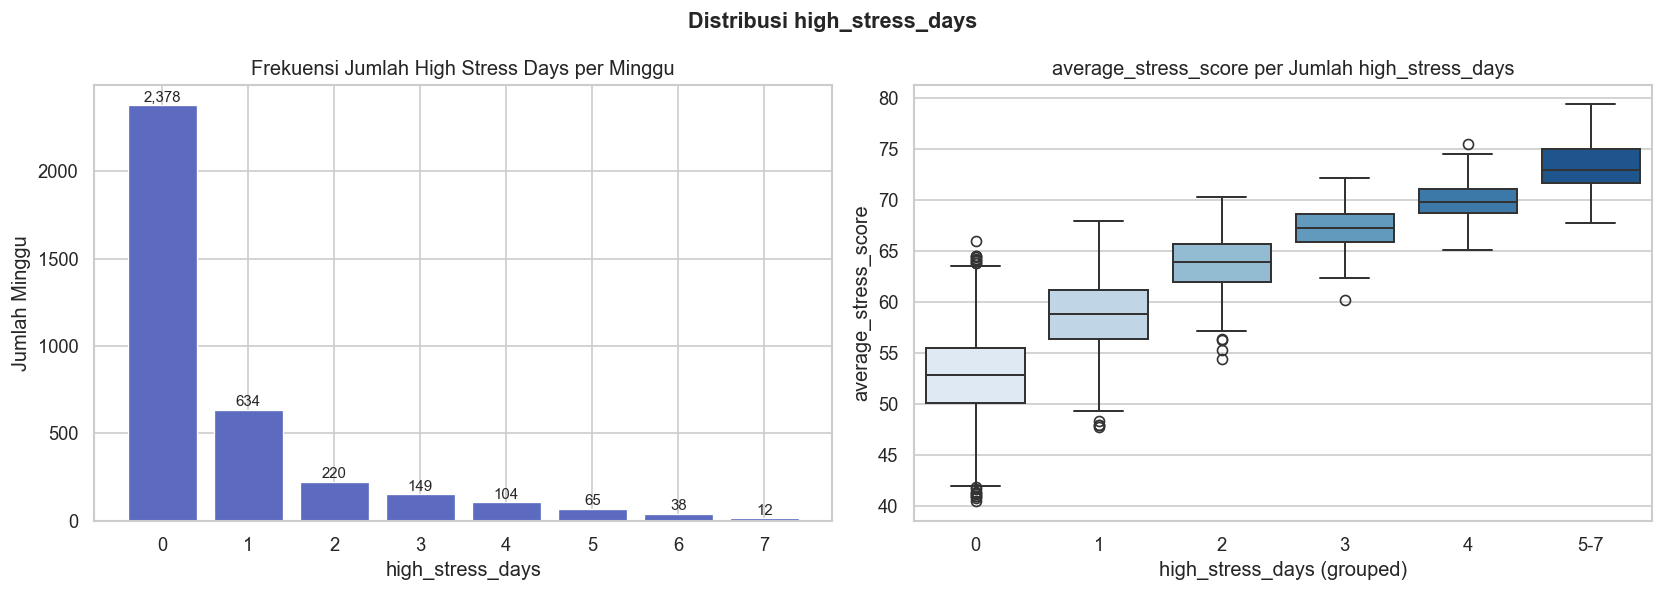


--- Rata-rata average_stress_score per high_stress_days bin ---
hsd_bin
0      52.79
1      58.65
2      63.55
3      67.08
4      69.88
5-7    73.20
Name: average_stress_score, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi high_stress_days', fontsize=13, fontweight='bold')

# --- Plot 1: Bar chart frekuensi per nilai ---
hsd_counts = weekly_eda['high_stress_days'].value_counts().sort_index()
bars = axes[0].bar(hsd_counts.index.astype(str), hsd_counts.values,
                   color='#5C6BC0', edgecolor='white', linewidth=0.8)
axes[0].set_title('Frekuensi Jumlah High Stress Days per Minggu')
axes[0].set_xlabel('high_stress_days')
axes[0].set_ylabel('Jumlah Minggu')
for bar, val in zip(bars, hsd_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# --- Plot 2: Boxplot average_stress_score by high_stress_days (binned) ---
weekly_eda['hsd_bin'] = pd.cut(
    weekly_eda['high_stress_days'],
    bins=[-1, 0, 1, 2, 3, 4, 7],
    labels=['0', '1', '2', '3', '4', '5-7']
)
sns.boxplot(data=weekly_eda, x='hsd_bin', y='average_stress_score',
            palette='Blues', ax=axes[1], linewidth=1.2)
axes[1].set_title('average_stress_score per Jumlah high_stress_days')
axes[1].set_xlabel('high_stress_days (grouped)')
axes[1].set_ylabel('average_stress_score')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '02_weekly_high_stress_days.png', bbox_inches='tight')
plt.show()

print('\n--- Rata-rata average_stress_score per high_stress_days bin ---')
print(weekly_eda.groupby('hsd_bin')['average_stress_score'].mean().round(2))

## Insight 

- **Mayoritas minggu tidak memiliki hari stres tinggi sama sekali**, sebanyak 2.378 minggu (66.1% dari total) mencatat `high_stress_days = 0`. Ini konsisten dengan dominasi Medium di Section 2, mahasiswa memang berada di zona stres sedang, namun jarang mengalami hari yang benar-benar berat dalam satu minggu penuh.

- **Terdapat hubungan positif yang sangat konsisten** antara `high_stress_days` dan `average_stress_score`. Rata-rata skor naik secara bertahap dan linear: dari 52.79 (0 hari) → 58.65 (1 hari) → 63.55 (2 hari) → 67.08 (3 hari) → 69.88 (4 hari) → 73.20 (5–7 hari). Setiap penambahan satu hari stres tinggi rata-rata menaikkan skor sekitar 4–6 poin.

- **Minggu dengan `high_stress_days = 5–7` sudah melampaui ambang batas High (≥70)** dengan rata-rata 73.20, dan boxplot-nya menunjukkan IQR yang sangat sempit di kisaran 72–74  artinya hampir semua minggu di kategori ini seragam tinggi, bukan kebetulan outlier. Meskipun hanya 115 minggu (3.2% dari data), kelompok ini merepresentasikan kondisi stres kronis yang perlu perhatian khusus.

# 4. Distribusi main_trigger 

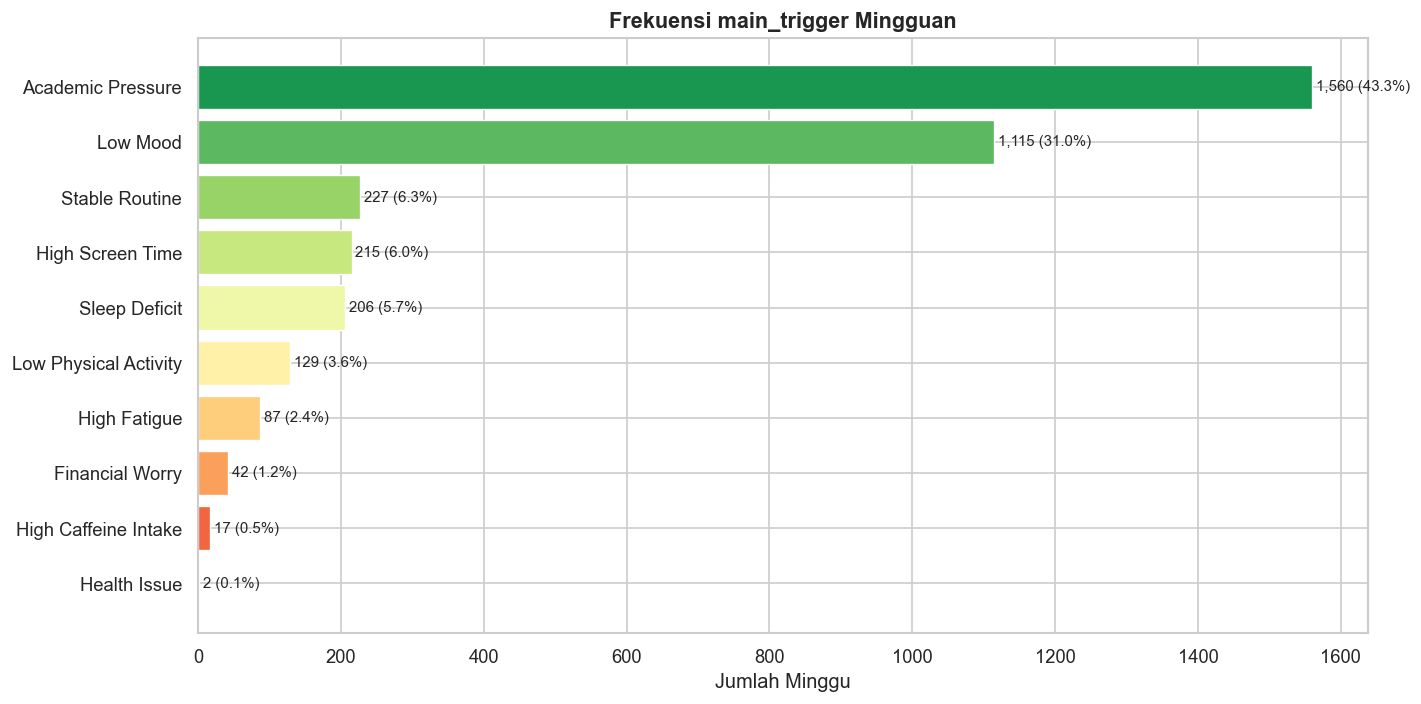


--- main_trigger counts ---
main_trigger
Academic Pressure        1560
Low Mood                 1115
Stable Routine            227
High Screen Time          215
Sleep Deficit             206
Low Physical Activity     129
High Fatigue               87
Financial Worry            42
High Caffeine Intake       17
Health Issue                2


In [6]:
trigger_counts = weekly_eda['main_trigger'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(trigger_counts)))
bars = ax.barh(trigger_counts.index[::-1], trigger_counts.values[::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.8)
ax.set_title('Frekuensi main_trigger Mingguan', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Minggu')
ax.set_ylabel('')
for bar, val in zip(bars, trigger_counts.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(weekly_eda)*100:.1f}%)',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '03_weekly_main_trigger.png', bbox_inches='tight')
plt.show()

# Save report
trigger_counts.reset_index(name='count').rename(
    columns={'main_trigger': 'main_trigger'}
).to_csv(OUTPUT_REPORTS / 'weekly_main_trigger_counts.csv', index=False)

print('\n--- main_trigger counts ---')
print(trigger_counts.to_string())

## Insight — Section 4: Distribusi main_trigger

- **Academic Pressure mendominasi secara signifikan** sebagai trigger utama stres mingguan dengan 1.560 minggu (43.3%). Hampir separuh dari seluruh minggu yang direkam, tekanan akademik menjadi faktor penentu stres, ini sangat konsisten dengan karakteristik populasi mahasiswa.

- **Low Mood berada di posisi kedua** dengan 1.115 minggu (31.0%). Gabungan Academic Pressure dan Low Mood mencakup 74.3% dari seluruh data, artinya 3 dari 4 minggu stres mahasiswa dipicu oleh dua faktor ini saja. Menariknya, Low Mood bisa jadi bukan penyebab independen melainkan efek lanjutan dari tekanan akademik yang berkepanjangan.

- **Trigger gaya hidup (Stable Routine, High Screen Time, Sleep Deficit) masing-masing hanya 5–6%**, dan trigger ekstrem seperti Financial Worry (1.2%), High Caffeine Intake (0.5%), serta Health Issue (0.1%) sangat jarang muncul. Distribusi yang sangat tidak merata ini penting untuk diperhatikan saat feature engineering.

# 5. Hubungan Weekly Features dengan average_stress_score

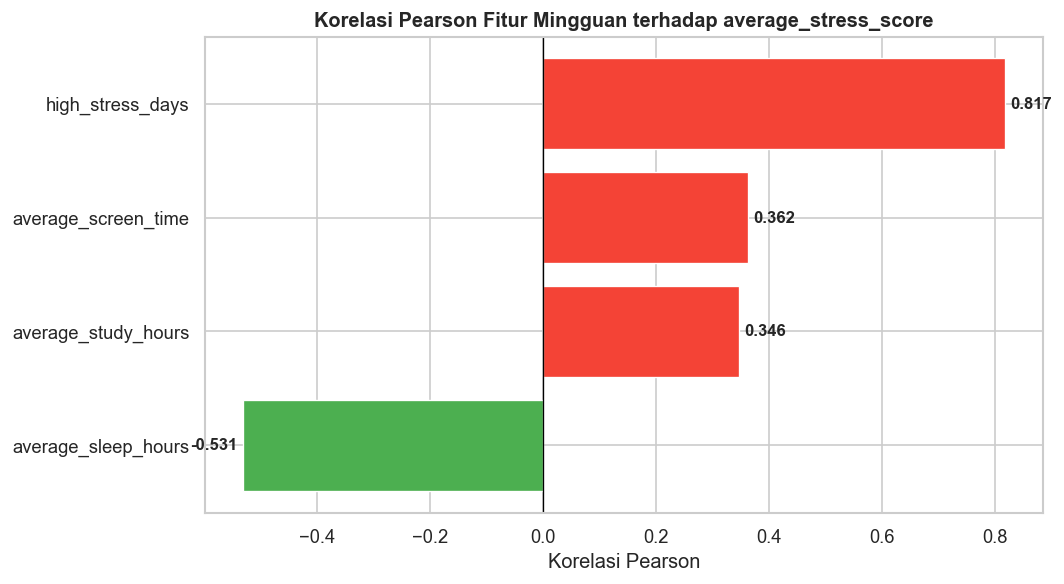


--- Korelasi Fitur Mingguan ---
average_sleep_hours   -0.5310
average_study_hours    0.3462
average_screen_time    0.3619
high_stress_days       0.8172
Name: average_stress_score, dtype: float64


In [7]:
# 5.1 Correlation ranking
corr_weekly = (
    weekly_eda[WEEKLY_NUM_COLS + ['average_stress_score']]
    .corr()['average_stress_score']
    .drop('average_stress_score')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4CAF50' if c < 0 else '#F44336' for c in corr_weekly.values]
bars = ax.barh(corr_weekly.index, corr_weekly.values,
               color=colors, edgecolor='white', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Pearson Fitur Mingguan terhadap average_stress_score',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Korelasi Pearson')
for bar, val in zip(bars, corr_weekly.values):
    offset = 0.01 if val >= 0 else -0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '04_weekly_feature_correlation.png', bbox_inches='tight')
plt.show()

# Save report
corr_weekly.reset_index().rename(
    columns={'index': 'feature', 'average_stress_score': 'pearson_corr'}
).to_csv(OUTPUT_REPORTS / 'weekly_feature_correlation_with_average_stress_score.csv', index=False)

print('\n--- Korelasi Fitur Mingguan ---')
print(corr_weekly.round(4))

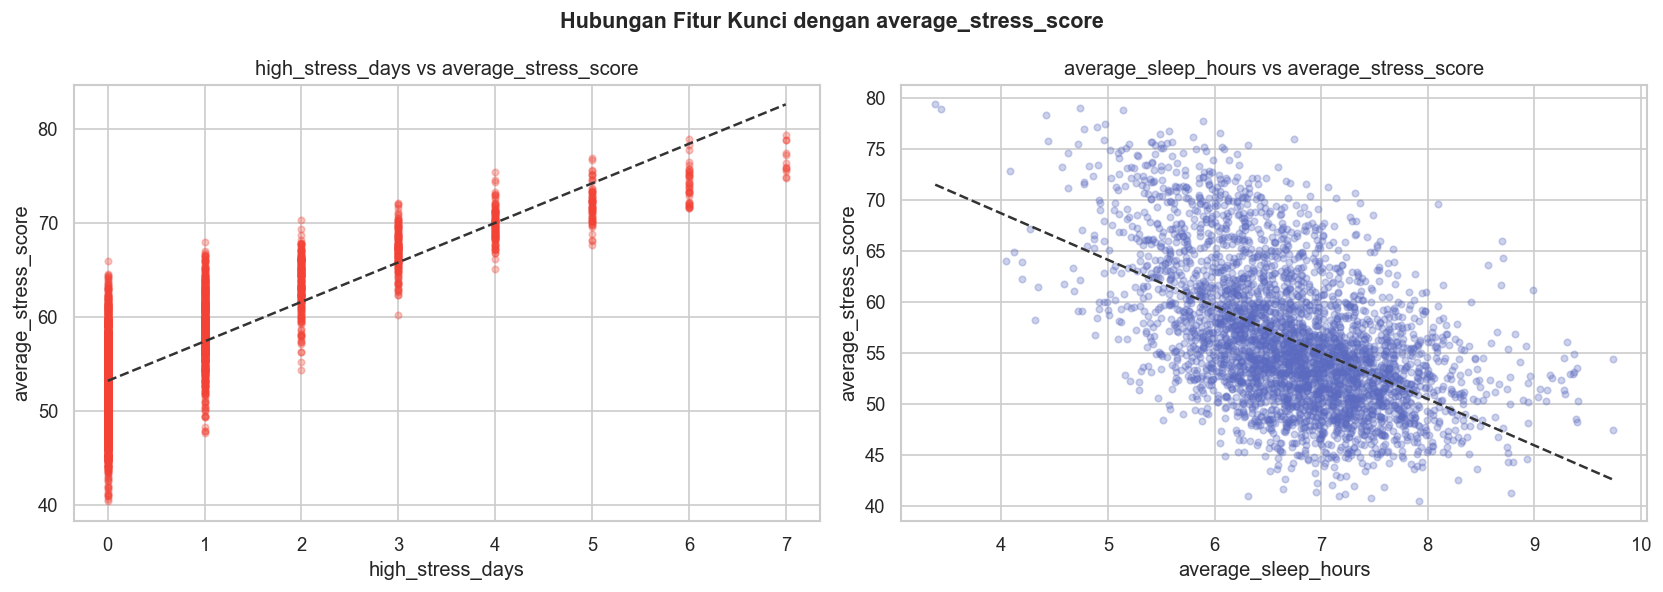

In [8]:
# 5.2 Scatter plot fitur paling berkorelasi: high_stress_days dan average_sleep_hours
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hubungan Fitur Kunci dengan average_stress_score', fontsize=13, fontweight='bold')

# high_stress_days vs average_stress_score
axes[0].scatter(weekly_eda['high_stress_days'],
                weekly_eda['average_stress_score'],
                alpha=0.3, color='#F44336', s=15)
axes[0].set_title('high_stress_days vs average_stress_score')
axes[0].set_xlabel('high_stress_days')
axes[0].set_ylabel('average_stress_score')
# Tambahkan trend line
z = np.polyfit(weekly_eda['high_stress_days'], weekly_eda['average_stress_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 7, 100)
axes[0].plot(x_line, p(x_line), color='#333', linewidth=1.5, linestyle='--')

# average_sleep_hours vs average_stress_score
axes[1].scatter(weekly_eda['average_sleep_hours'],
                weekly_eda['average_stress_score'],
                alpha=0.3, color='#5C6BC0', s=15)
axes[1].set_title('average_sleep_hours vs average_stress_score')
axes[1].set_xlabel('average_sleep_hours')
axes[1].set_ylabel('average_stress_score')
z2 = np.polyfit(weekly_eda['average_sleep_hours'], weekly_eda['average_stress_score'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(weekly_eda['average_sleep_hours'].min(),
                       weekly_eda['average_sleep_hours'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), color='#333', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '05_weekly_key_feature_scatter.png', bbox_inches='tight')
plt.show()

## Insight 

- **`high_stress_days` adalah prediktor terkuat** dengan korelasi Pearson 0.817ini tergolong korelasi yang sangat kuat. Scatter plot-nya pun memperlihatkan pola yang hampir deterministik: titik-titik data berkelompok rapat di tiap nilai integer, dan tren naik mengikuti garis lurus dengan sangat konsisten. Artinya, `high_stress_days` bukan sekadar berkorelasi, ia hampir mendefinisikan level skor stres mingguan.

- **`average_sleep_hours` adalah satu-satunya fitur dengan korelasi negatif** (−0.531), dan ini adalah korelasi terkuat kedua. Scatter plot-nya menunjukkan sebaran yang lebih lebar dibanding `high_stress_days`, namun tren turunnya jelas semakin banyak jam tidur, semakin rendah skor stres. Ini menjadikan tidur sebagai faktor protektif yang paling terukur di antara semua fitur gaya hidup mingguan.

- **`average_screen_time` (0.362) dan `average_study_hours` (0.346) memiliki korelasi positif yang moderat dan hampir sejajar**. Keduanya berkontribusi terhadap stres, namun jauh lebih lemah dibanding `high_stress_days`. Selisil keduanya hanya 0.016, sehingga tidak bisa disimpulkan salah satunya secara jelas lebih berpengaruh dari yang lain, keduanya berada di level kontribusi yang serupa terhadap `average_stress_score`.

# 6. Analisis average_stress_score berdasarkan stress_trend

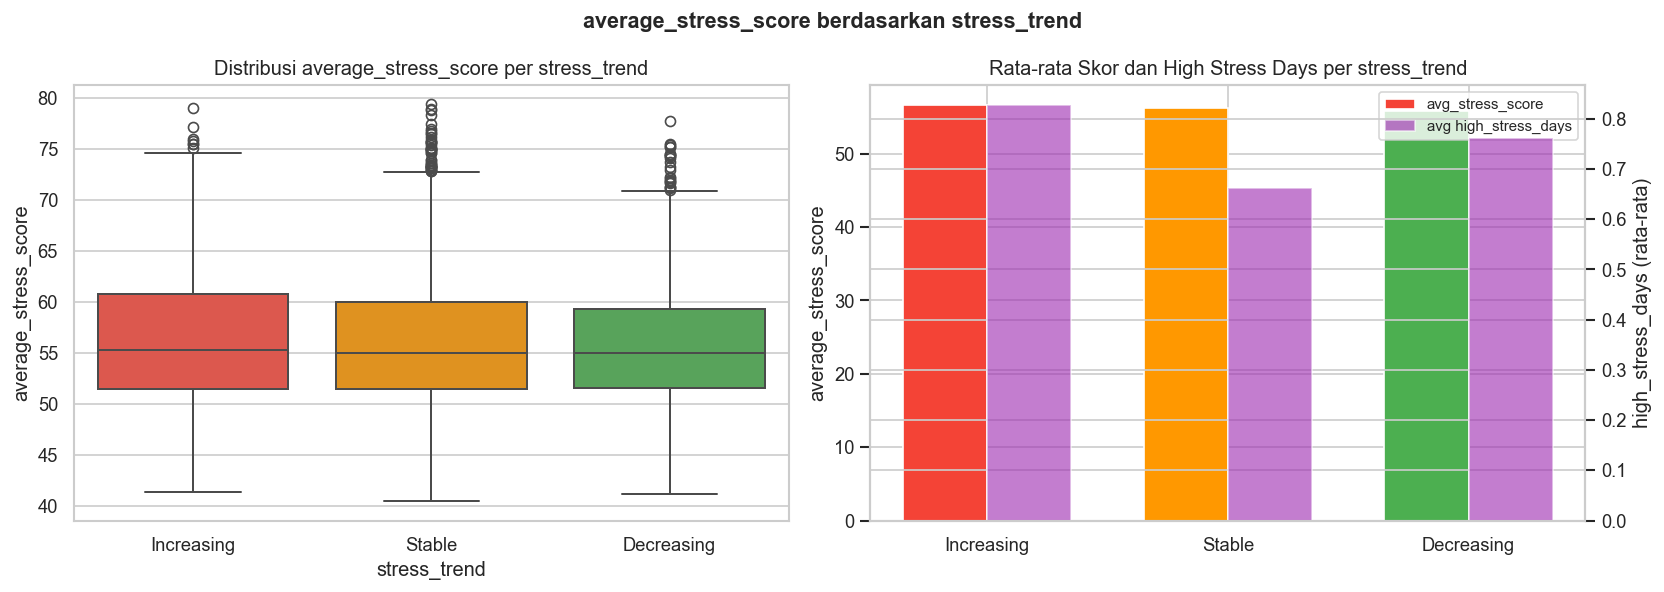


--- Rata-rata Fitur per stress_trend ---
              average_stress_score  average_sleep_hours  average_screen_time  \
stress_trend                                                                   
Increasing                  56.593                6.701                6.726   
Stable                      56.237                6.750                6.757   
Decreasing                  55.837                6.721                6.649   

              average_study_hours  high_stress_days  
stress_trend                                         
Increasing                  4.213             0.827  
Stable                      4.137             0.663  
Decreasing                  4.081             0.763  


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('average_stress_score berdasarkan stress_trend', fontsize=13, fontweight='bold')

# --- Plot 1: Boxplot ---
sns.boxplot(data=weekly_eda, x='stress_trend', y='average_stress_score',
            order=TREND_ORDER, palette=TREND_PALETTE,
            ax=axes[0], linewidth=1.2)
axes[0].set_title('Distribusi average_stress_score per stress_trend')
axes[0].set_xlabel('stress_trend')
axes[0].set_ylabel('average_stress_score')

# --- Plot 2: Mean barplot + mean high_stress_days ---
mean_by_trend = weekly_eda.groupby('stress_trend')[
    ['average_stress_score', 'high_stress_days']
].mean().reindex(TREND_ORDER)

x = np.arange(len(TREND_ORDER))
width = 0.35
bars1 = axes[1].bar(x - width/2, mean_by_trend['average_stress_score'],
                    width, color=[TREND_PALETTE[t] for t in TREND_ORDER],
                    label='avg_stress_score', edgecolor='white')
ax2 = axes[1].twinx()
bars2 = ax2.bar(x + width/2, mean_by_trend['high_stress_days'],
                width, color='#9C27B0', alpha=0.6,
                label='avg high_stress_days', edgecolor='white')
axes[1].set_title('Rata-rata Skor dan High Stress Days per stress_trend')
axes[1].set_xticks(x)
axes[1].set_xticklabels(TREND_ORDER)
axes[1].set_ylabel('average_stress_score')
ax2.set_ylabel('high_stress_days (rata-rata)')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '06_weekly_stress_by_trend.png', bbox_inches='tight')
plt.show()

# Save report
trend_summary = weekly_eda.groupby('stress_trend')[
    ['average_stress_score', 'average_sleep_hours', 'average_screen_time',
     'average_study_hours', 'high_stress_days']
].agg(['mean', 'std']).round(3)
trend_summary.to_csv(OUTPUT_REPORTS / 'weekly_stress_trend_summary.csv')

print('\n--- Rata-rata Fitur per stress_trend ---')
print(weekly_eda.groupby('stress_trend')[
    ['average_stress_score', 'average_sleep_hours',
     'average_screen_time', 'average_study_hours', 'high_stress_days']
].mean().reindex(TREND_ORDER).round(3))

## Insight — Section 6: average_stress_score berdasarkan stress_trend

- **Perbedaan `average_stress_score` antar ketiga tren sangat kecil**, Increasing (56.59), Stable (56.24), Decreasing (55.84). Selisih antara tertinggi dan terendah hanya 0.76 poin, dan boxplot ketiga kelompok pun hampir identik dengan median di kisaran 55–56. Artinya, `stress_trend` tidak mencerminkan perbedaan level stres absolut, melainkan arah perubahan stres dalam satu minggu.

- **`high_stress_days` memberikan pembeda yang lebih bermakna** antar tren dibanding skor stres itu sendiri. Kelompok Increasing rata-rata memiliki 0.827 hari stres tinggi per minggu, lebih banyak dari stable (0.663) dan Decreasing (0.763). Ini menunjukkan bahwa minggu dengan tren meningkat cenderung memiliki lebih banyak hari berat, yang kemudian mendorong skor naik ke depannya.

- **Fitur gaya hidup (`average_sleep_hours`, `average_screen_time`, `average_study_hours`) hampir tidak berbeda antar tren**, selisihnya di bawah 0.1 jam untuk semua fitur. Ini mengindikasikan bahwa `stress_trend` tidak bisa dijelaskan semata dari perilaku gaya hidup mingguan rata-rata. Faktor yang lebih menentukan tren kemungkinan adalah dinamika harian yang tidak tertangkap dalam agregasi mingguan, seperti urutan kejadian atau fluktuasi antar hari.

# 7. Analisis dominant_stress_level

In [10]:
# Konfirmasi jumlah sample per dominant_stress_level
level_counts_check = weekly_eda['dominant_stress_level'].value_counts().reindex(LEVEL_ORDER)
print('--- Sample count per dominant_stress_level ---')
for lvl, cnt in level_counts_check.items():
    flag = '⚠️  sangat sedikit, tidak representatif' if cnt < 10 else ''
    print(f'  {lvl:8s}: {cnt:,} minggu {flag}')
print()

--- Sample count per dominant_stress_level ---
  Low     : 2 minggu ⚠️  sangat sedikit, tidak representatif
  Medium  : 3,379 minggu 
  High    : 219 minggu 



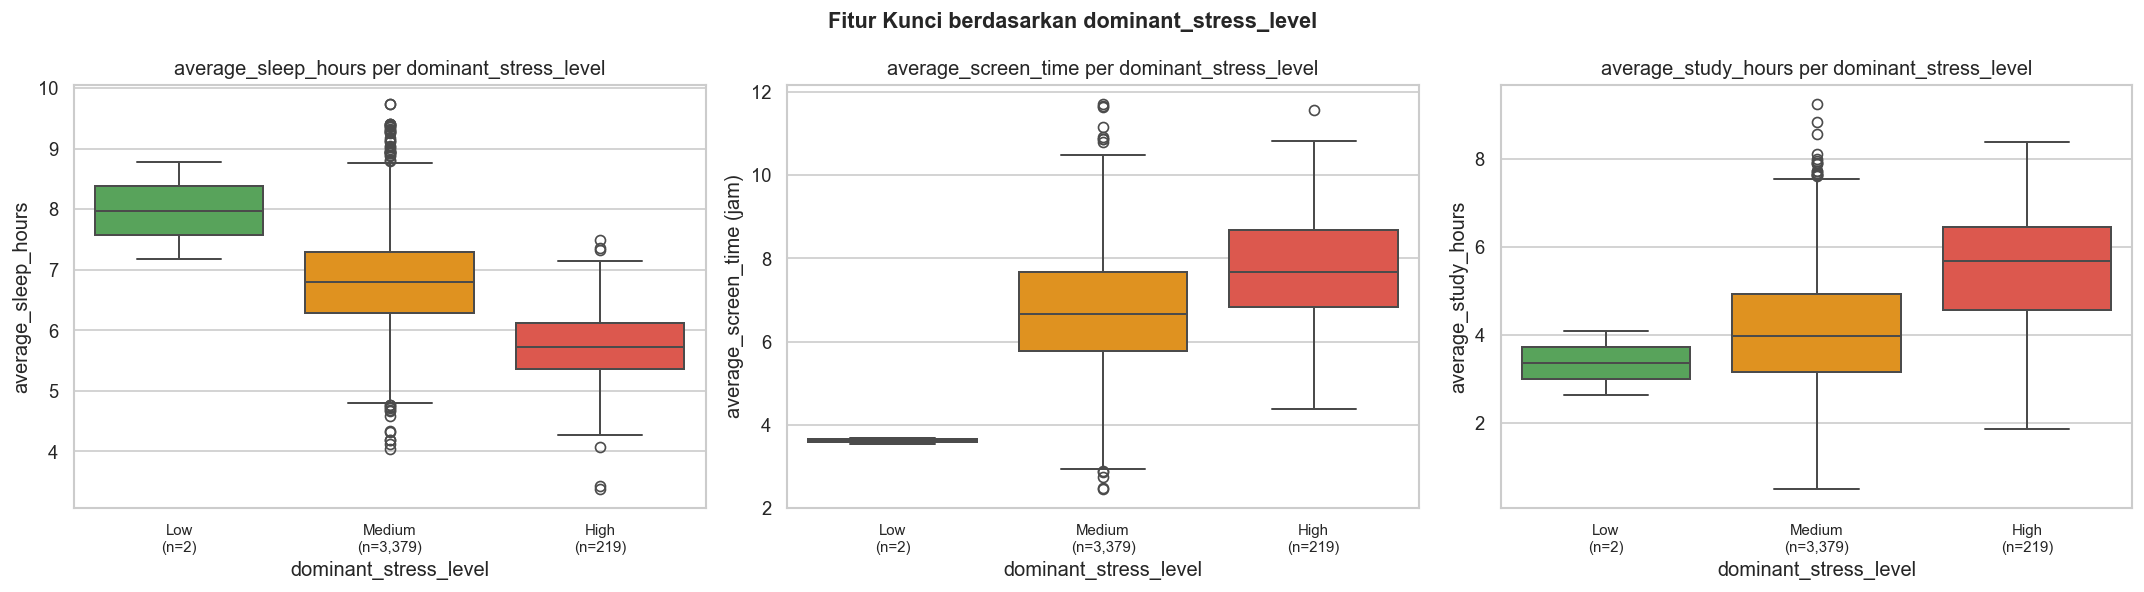


--- Rata-rata Fitur per dominant_stress_level ---
                       average_stress_score  average_sleep_hours  \
dominant_stress_level                                              
Low                                  41.090                7.975   
Medium                               55.225                6.800   
High                                 71.623                5.721   

                       average_screen_time  average_study_hours  \
dominant_stress_level                                             
Low                                  3.615                3.365   
Medium                               6.668                4.051   
High                                 7.690                5.503   

                       high_stress_days  
dominant_stress_level                    
Low                               0.000  
Medium                            0.450  
High                              4.808  


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fitur Kunci berdasarkan dominant_stress_level', fontsize=13, fontweight='bold')

PLOT_COLS = ['average_sleep_hours', 'average_screen_time', 'average_study_hours']
YLABELS   = ['average_sleep_hours', 'average_screen_time (jam)', 'average_study_hours']

for i, (col, ylabel) in enumerate(zip(PLOT_COLS, YLABELS)):
    sns.boxplot(data=weekly_eda, x='dominant_stress_level', y=col,
                order=LEVEL_ORDER, palette=LEVEL_PALETTE,
                ax=axes[i], linewidth=1.2)
    axes[i].set_title(f'{col} per dominant_stress_level')
    axes[i].set_xlabel('dominant_stress_level')
    axes[i].set_ylabel(ylabel)

    # Annotation n= per kategori
    new_labels = [
        f'{lvl}\n(n={level_counts_check.get(lvl, 0):,})'
        for lvl in LEVEL_ORDER
    ]
    axes[i].set_xticklabels(new_labels, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '07_weekly_features_by_dominant_level.png', bbox_inches='tight')
plt.show()

print('\n--- Rata-rata Fitur per dominant_stress_level ---')
print(weekly_eda.groupby('dominant_stress_level')[
    ['average_stress_score', 'average_sleep_hours',
     'average_screen_time', 'average_study_hours', 'high_stress_days']
].mean().reindex(LEVEL_ORDER).round(3))

## Insight — Section 7: Fitur Kunci berdasarkan dominant_stress_level

- Kategori Low hanya terdiri dari 2 minggu (0.1%) sehingga tidak representatif. Perbandingan valid hanya antara Medium (n=3.379) dan High (n=219).

- average_sleep_hours turun dari 6.800 jam (Medium) menjadi 5.721 jam (High), selisih 1.1 jam per malam. Mahasiswa High stress secara konsisten kurang tidur, bukan hanya sesekali.

- Mahasiswa High stress juga belajar lebih lama (5.503 vs 4.051 jam) dan menghabiskan lebih banyak waktu di layar (7.690 vs 6.668 jam), mengindikasikan minggu yang lebih padat secara keseluruhan.

- high_stress_days adalah pembeda paling tajam. Medium rata-rata 0.450 hari per minggu, High mencapai 4.808 hari. Lompatan 10 kali lipat ini menunjukkan bahwa dominant_stress_level High adalah kondisi yang secara kualitatif berbeda, bukan sekadar skor yang sedikit lebih tinggi.

# 8. Export Summary Reports

In [12]:
# Daftar file yang seharusnya sudah tersimpan
expected_reports = [
    OUTPUT_REPORTS / 'weekly_feature_correlation_with_average_stress_score.csv',
    OUTPUT_REPORTS / 'weekly_stress_trend_summary.csv',
    OUTPUT_REPORTS / 'weekly_main_trigger_counts.csv',
    OUTPUT_REPORTS / 'weekly_feature_summary_by_dominant_level.csv',
]

expected_figures = [
    OUTPUT_FIGURES / '01_weekly_target_distribution.png',
    OUTPUT_FIGURES / '02_weekly_high_stress_days.png',
    OUTPUT_FIGURES / '03_weekly_main_trigger.png',
    OUTPUT_FIGURES / '04_weekly_feature_correlation.png',
    OUTPUT_FIGURES / '05_weekly_key_feature_scatter.png',
    OUTPUT_FIGURES / '06_weekly_stress_by_trend.png',
    OUTPUT_FIGURES / '07_weekly_features_by_dominant_level.png',
]

print('--- Output Reports ---')
for f in expected_reports:
    status = '✅ saved' if f.exists() else '❌ NOT FOUND'
    print(f'  {status}  {f.name}')

print('\n--- Output Figures ---')
for f in expected_figures:
    status = '✅ saved' if f.exists() else '❌ NOT FOUND'
    print(f'  {status}  {f.name}')

--- Output Reports ---
  ✅ saved  weekly_feature_correlation_with_average_stress_score.csv
  ✅ saved  weekly_stress_trend_summary.csv
  ✅ saved  weekly_main_trigger_counts.csv
  ✅ saved  weekly_feature_summary_by_dominant_level.csv

--- Output Figures ---
  ✅ saved  01_weekly_target_distribution.png
  ✅ saved  02_weekly_high_stress_days.png
  ✅ saved  03_weekly_main_trigger.png
  ✅ saved  04_weekly_feature_correlation.png
  ✅ saved  05_weekly_key_feature_scatter.png
  ✅ saved  06_weekly_stress_by_trend.png
  ✅ saved  07_weekly_features_by_dominant_level.png


# 9. Conclusion 


- Pola stres mingguan mahasiswa secara umum berada di zona Medium, dengan `average_stress_score` rata-rata 56.2 dan 93.9% minggu berkategori `dominant_stress_level` Medium. Stres berat (High) hanya terjadi pada 6.1% minggu, namun kelompok ini menunjukkan kondisi yang secara kualitatif berbeda dari kelompok Medium.

- `high_stress_days` adalah faktor paling dominan dalam menentukan level stres mingguan, dengan korelasi Pearson 0.817. Semakin banyak hari stres tinggi dalam satu minggu, semakin besar skor stresnya secara konsisten. Di sisi lain, `average_sleep_hours` adalah satu-satunya faktor protektif yang terukur, dengan korelasi negatif -0.531. Mahasiswa High stress rata-rata tidur 1.1 jam lebih sedikit dibanding Medium.

- `Academic Pressure` mendominasi sebagai `main_trigger` (43.3%), diikuti `Low Mood` (31.0%). Keduanya mencakup 74.3% dari seluruh minggu, menunjukkan bahwa tekanan akademik dan kondisi emosional adalah akar utama stres mingguan mahasiswa.

- `stress_trend` tidak mencerminkan perbedaan level stres absolut karena rata-rata `average_stress_score` antar tren hanya berbeda 0.76 poin. Tren lebih menggambarkan arah perubahan, bukan intensitas stres itu sendiri.

# Business Answer Question

> **Bagaimana pola stres mingguan mahasiswa berdasarkan `average_stress_score`, `dominant_stress_level`, `stress_trend`, `high_stress_days`, dan `main_trigger`?**

Mayoritas mahasiswa berada dalam kondisi stres sedang yang konstan. `average_stress_score` rata-rata 56.2, `dominant_stress_level` Medium mendominasi 93.9% minggu, dan `stress_trend` Stable paling sering muncul (59.8%). Stres bukan kondisi ekstrem, namun juga tidak pernah benar-benar absen.

- **Apakah jumlah `high_stress_days` berkaitan dengan peningkatan `average_stress_score`?**

    Ya, dan hubungannya sangat kuat (r=0.817). Rata-rata skor naik dari 52.79 (0 hari) hingga 73.20 (5-7 hari). Setiap penambahan hari stres tinggi secara konsisten menaikkan skor rata-rata minggu tersebut.

- **Stress trend apa yang paling sering muncul pada mahasiswa?**

    `stress_trend` Stable paling dominan dengan 2.153 minggu (59.8%), diikuti Decreasing (21.9%) dan Increasing (18.3%). Namun ketiga tren memiliki rata-rata `average_stress_score` yang hampir identik, sehingga tren lebih menggambarkan arah perubahan bukan intensitas stres.

- **Faktor mingguan apa yang paling sering menjadi `main_trigger` stres?** 

    `Academic Pressure` (43.3%) dan `Low Mood` (31.0%) mendominasi dan bersama-sama mencakup 74.3% seluruh data. Faktor gaya hidup lainnya seperti `Sleep Deficit` dan `High Screen Time` masing-masing hanya berkontribusi di bawah 6%.

- **Apakah `average_sleep_hours` memiliki hubungan dengan `dominant_stress_level`?** 

    Ya. Mahasiswa dengan `dominant_stress_level` High rata-rata tidur 5.721 jam per malam, dibanding 6.800 jam pada kelompok Medium. Korelasi negatif -0.531 antara `average_sleep_hours` dan `average_stress_score` mengkonfirmasi tidur sebagai faktor protektif yang konsisten.

- **Bagaimana hubungan antara `average_screen_time` dan `stress_trend` mingguan?** 

    Perbedaan `average_screen_time` antar tren sangat kecil: Increasing (6.726 jam), Stable (6.757 jam), Decreasing (6.649 jam). Screen time tidak membedakan tren secara bermakna, namun pada level High stress, screen time meningkat ke 7.690 jam dibanding 6.668 jam pada Medium.

- **Apakah mahasiswa dengan `average_study_hours` tinggi cenderung memiliki stres mingguan lebih tinggi?**

    Tidak secara langsung. Korelasi antara `average_study_hours` dan `average_stress_score` hanya 0.346, tergolong moderat. Mahasiswa High stress memang belajar lebih lama rata-rata (5.503 vs 4.051 jam), namun durasi belajar bukan satu-satunya penentu karena faktor seperti `high_stress_days` dan `average_sleep_hours` jauh lebih berpengaruh.

# 10. Suggestion 


- Untuk feature engineering, `high_stress_days` dan `average_sleep_hours` adalah fitur prioritas karena keduanya memiliki korelasi tertinggi terhadap `average_stress_score`. Fitur interaksi antara keduanya layak dipertimbangkan.

- `main_trigger` perlu penanganan khusus saat encoding karena distribusinya sangat tidak merata, dengan Health Issue hanya 2 minggu (0.1%) dibanding Academic Pressure 1.560 minggu (43.3%).

- Untuk analisis lanjutan, segmentasi mahasiswa berdasarkan kombinasi `stress_trend` dan `dominant_stress_level` dapat mengidentifikasi kelompok prioritas intervensi, khususnya kelompok dengan tren Increasing yang memiliki rata-rata `high_stress_days` tertinggi (0.827 hari per minggu).
